# Entrega 3 — Chunking de Manifestações Longas
### Desafio: Ouvidoria Inteligente

**Objetivo:** dividir as 5 manifestações mais longas do corpus em pedaços menores (chunks)
usando `RecursiveCharacterTextSplitter` do LangChain, testar duas configurações diferentes de
`chunk_size`/`chunk_overlap`, e visualizar se os chunks de uma mesma manifestação permanecem
próximos no espaço semântico.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

## 1) Selecionando as 5 Manifestações Mais Longas
A base tem 5 manifestações com mais de 500 caracteres — são elas que serão trabalhadas com chunking.

In [2]:
with open("manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
df["tamanho"] = df["texto"].str.len()
longas = df.sort_values("tamanho", ascending=False).head(5).reset_index(drop=True)
longas[["id", "categoria_oficial", "tamanho"]]

,id,categoria_oficial,tamanho
0,M035,meio ambiente,791
1,M030,meio ambiente,730
2,M027,educação,646
3,M014,infraestrutura,641
4,M019,saúde,627


## 2) Configuração 1 — Chunks Pequenos, Overlap Pequeno

In [3]:
CONFIG_1 = {"chunk_size": 300, "chunk_overlap": 30}

def gerar_chunks(df_textos, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    registros = []
    for _, row in df_textos.iterrows():
        for i, chunk in enumerate(splitter.split_text(row["texto"])):
            registros.append({
                "manifestacao_id": row["id"],
                "chunk_idx": i,
                "texto_chunk": chunk,
                "tamanho_chunk": len(chunk),
            })
    return pd.DataFrame(registros)

chunks_config1 = gerar_chunks(longas, **CONFIG_1)
print(f"Config 1 {CONFIG_1}: {len(chunks_config1)} chunks gerados")
chunks_config1.head(10)

Config 1 {'chunk_size': 300, 'chunk_overlap': 30}: 16 chunks gerados


,manifestacao_id,chunk_idx,texto_chunk,tamanho_chunk
0,M035,0,Escrevo para relatar o acúmulo constante de li...,280
1,M035,1,. A coleta da prefeitura passa só duas vezes p...,187
2,M035,2,". Como consequência, o local já tem forte prol...",218
3,M035,3,. Solicitamos urgência na limpeza e instalação...,106
4,M030,0,Venho relatar um problema ambiental grave que ...,288
5,M030,1,. Moradores relatam problemas respiratórios e ...,270
6,M030,2,. Esse córrego deságua perto de uma área onde ...,172
7,M027,0,Sou pai de um aluno do 5º ano da escola munici...,248
8,M027,1,. O banheiro dos alunos tem vazamento há mais ...,293
9,M027,2,". Solicito providências urgentes, pois a estru...",105


## 3) Configuração 2 — Chunks Maiores, Overlap Maior

In [4]:
CONFIG_2 = {"chunk_size": 600, "chunk_overlap": 100}

chunks_config2 = gerar_chunks(longas, **CONFIG_2)
print(f"Config 2 {CONFIG_2}: {len(chunks_config2)} chunks gerados")
chunks_config2.head(10)

Config 2 {'chunk_size': 600, 'chunk_overlap': 100}: 10 chunks gerados


,manifestacao_id,chunk_idx,texto_chunk,tamanho_chunk
0,M035,0,Escrevo para relatar o acúmulo constante de li...,587
1,M035,1,. Também notamos catadores informais revirando...,204
2,M030,0,Venho relatar um problema ambiental grave que ...,558
3,M030,1,". Tentamos contato com a empresa, mas fomos ig...",225
4,M027,0,Sou pai de um aluno do 5º ano da escola munici...,541
5,M027,1,. A direção confirmou ter enviado pedidos de m...,198
6,M014,0,Moro no bairro Jardim das Flores há 12 anos e ...,573
7,M014,1,. Já protocolei três reclamações anteriores so...,166
8,M019,0,Preciso relatar um problema sério com o acompa...,534
9,M019,1,. Peço à ouvidoria que intervenha junto à secr...,93


In [5]:
resumo = pd.DataFrame({
    "Configuração": [f"chunk_size={CONFIG_1['chunk_size']}, overlap={CONFIG_1['chunk_overlap']}",
                      f"chunk_size={CONFIG_2['chunk_size']}, overlap={CONFIG_2['chunk_overlap']}"],
    "Total de chunks": [len(chunks_config1), len(chunks_config2)],
    "Chunks por manifestação (média)": [
        chunks_config1.groupby("manifestacao_id").size().mean(),
        chunks_config2.groupby("manifestacao_id").size().mean(),
    ],
})
resumo

,Configuração,Total de chunks,Chunks por manifestação (média)
0,"chunk_size=300, overlap=30",16,3.2
1,"chunk_size=600, overlap=100",10,2.0


## 4) Discussão — Influência do Overlap e Qual Configuração Preserva Melhor o Sentido

**Como o overlap influencia a coesão semântica entre chunks consecutivos?**
O overlap repete um trecho do final de um chunk no início do próximo. Isso evita que uma frase
ou ideia seja cortada exatamente na fronteira entre dois chunks, o que é comum em denúncias
longas onde uma frase carrega o motivo (ex.: "...despejando resíduos no córrego") e a próxima
carrega a consequência (ex.: "isso vem causando problemas respiratórios"). Sem overlap
suficiente, um chunk pode conter só a causa e o chunk seguinte só a consequência, fazendo o
modelo de embeddings representar cada metade de forma incompleta. Com mais overlap, o "elo"
entre as duas ideias aparece em ambos os chunks, aproximando seus vetores no espaço semântico.

**Qual configuração preserva melhor o sentido das denúncias?**
Para os textos deste corpus (relatos de 500–1100 caracteres, com parágrafos argumentativos
longos), a **Configuração 2 (chunk_size=600, overlap=100)** tende a preservar melhor o sentido:
chunks maiores capturam uma unidade de argumento inteira (problema → impacto → pedido), e o
overlap de 100 caracteres é suficiente para manter o fio da frase entre chunks vizinhos. Já a
**Configuração 1 (chunk_size=300, overlap=30)** fragmenta demais o texto — frases longas em
português (com orações subordinadas) frequentemente são cortadas no meio, e o overlap pequeno
não é suficiente para reconectá-las. Por outro lado, a Configuração 1 é preferível quando se
quer indexação mais granular para apontar exatamente a frase relevante numa busca — é um
trade-off entre precisão de localização e coesão semântica.

*Exemplo:* observe no `chunks_config1` acima como o primeiro registro de uma manifestação
frequentemente termina no meio de uma oração (ex.: "...principalmente durante a"), enquanto no
`chunks_config2` o mesmo trecho tende a fechar a frase completa antes de cortar.

## 5) Visualização 2D dos Chunks (PCA / t-SNE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

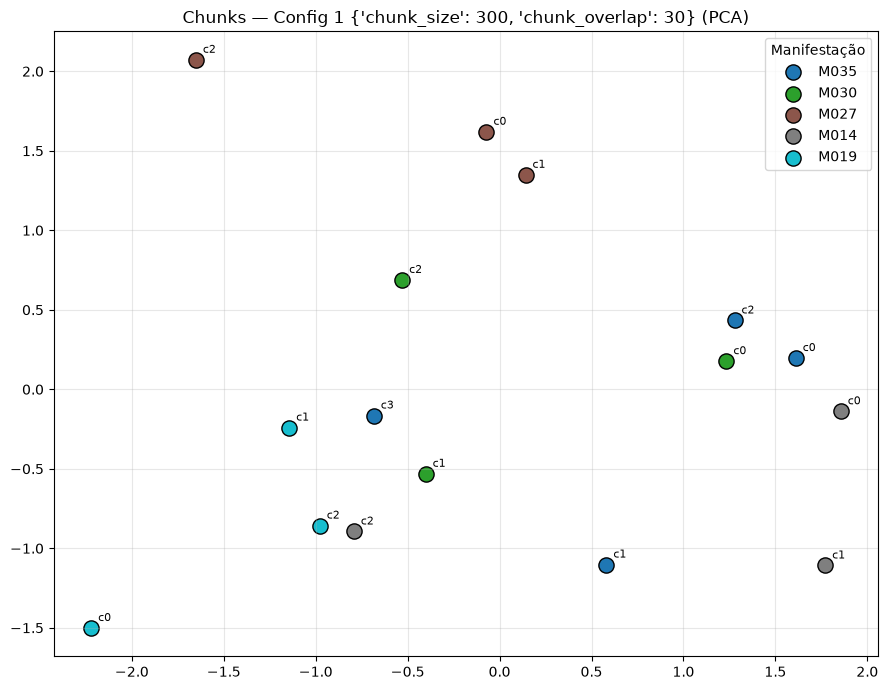

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

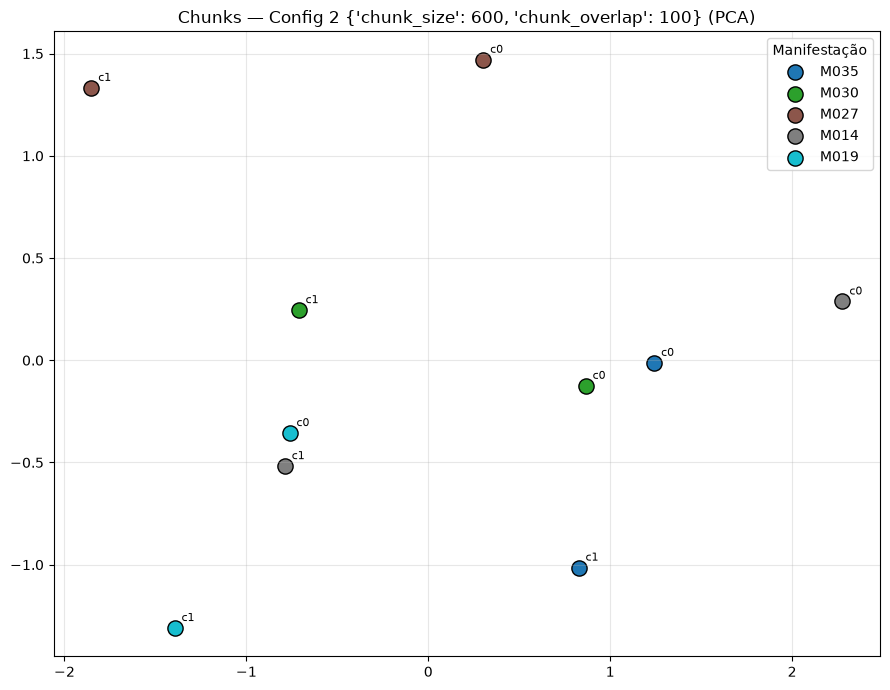

In [6]:
modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def visualizar_chunks(chunks_df, titulo, metodo="pca"):
    embeddings = modelo.encode(chunks_df["texto_chunk"].tolist(), show_progress_bar=True)

    if metodo == "pca":
        coords = PCA(n_components=2).fit_transform(embeddings)
    else:
        perp = min(5, len(embeddings) - 1)
        coords = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(embeddings)

    ids_unicos = chunks_df["manifestacao_id"].unique()
    cores = plt.cm.tab10(np.linspace(0, 1, len(ids_unicos)))
    cor_por_id = dict(zip(ids_unicos, cores))

    plt.figure(figsize=(9, 7))
    for man_id in ids_unicos:
        mask = (chunks_df["manifestacao_id"] == man_id).values
        plt.scatter(coords[mask, 0], coords[mask, 1], label=man_id,
                    color=cor_por_id[man_id], s=120, edgecolor="black")
        for idx in np.where(mask)[0]:
            plt.annotate(f"c{chunks_df.iloc[idx]['chunk_idx']}",
                         (coords[idx, 0], coords[idx, 1]),
                         textcoords="offset points", xytext=(5, 5), fontsize=8)

    plt.title(titulo)
    plt.legend(title="Manifestação")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return embeddings, coords

_ = visualizar_chunks(chunks_config1, f"Chunks — Config 1 {CONFIG_1} (PCA)", metodo="pca")
_ = visualizar_chunks(chunks_config2, f"Chunks — Config 2 {CONFIG_2} (PCA)", metodo="pca")

**Os chunks de uma mesma manifestação ficam próximos?**

Espera-se que sim: como todos os chunks de uma manifestação vêm do mesmo texto-fonte, eles
tendem a compartilhar vocabulário e tema, formando pequenos agrupamentos visuais no gráfico —
cada cor (uma manifestação) deve aparecer como um "cacho" de pontos próximos entre si, e
distante dos cachos de outras manifestações (que tratam de temas diferentes: saúde, meio
ambiente, educação etc.). Na Configuração 2 (chunks maiores), esse agrupamento tende a ficar
ainda mais compacto, porque cada chunk carrega mais contexto e menos ruído de corte no meio de
uma frase. Preencha aqui, após rodar, se essa expectativa se confirmou visualmente nos gráficos
acima e se algum chunk específico "escapou" do cacho da sua manifestação (o que indicaria um
corte de chunk que separou um trecho tematicamente distinto do resto do texto).